In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
insurance = pd.read_csv("data/insurance_medical_cost.csv")

In [5]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,56,female,27.02,2,no,northwest,23156.27
1,46,male,29.40,1,no,southwest,19456.82
2,32,female,25.97,5,no,northwest,20395.06
3,60,female,30.80,1,no,northwest,26350.83
4,25,female,26.81,0,no,southwest,13844.33


In [6]:
insurance.shape

(1338, 7)

In [7]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [8]:
insurance.info

<bound method DataFrame.info of       age     sex    bmi  children smoker     region   charges
0      56  female  27.02         2     no  northwest  23156.27
1      46    male  29.40         1     no  southwest  19456.82
2      32  female  25.97         5     no  northwest  20395.06
3      60  female  30.80         1     no  northwest  26350.83
4      25  female  26.81         0     no  southwest  13844.33
...   ...     ...    ...       ...    ...        ...       ...
1333   60  female  30.87         2     no  northwest  23521.39
1334   63    male  31.77         3    yes  northwest  61074.14
1335   21  female  27.19         0     no  southeast  14774.56
1336   43  female  29.42         3     no  northwest  21596.07
1337   46    male  26.55         0     no  northeast  18149.82

[1338 rows x 7 columns]>

In [9]:
insurance.duplicated().sum()

np.int64(0)

In [10]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,30.448475,1.092676,26947.834066
std,13.528861,5.966884,1.228710,12996.479469
min,18.000000,15.960000,0.000000,8783.150000
25%,29.000000,26.332500,0.000000,18667.667500
50%,42.000000,30.620000,1.000000,22391.445000
75%,52.000000,34.510000,2.000000,27196.797500
max,64.000000,47.260000,5.000000,63770.430000


In [12]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [13]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,56,female,27.02,2,no,northwest,23156.27
1,46,male,29.40,1,no,southwest,19456.82
2,32,female,25.97,5,no,northwest,20395.06
3,60,female,30.80,1,no,northwest,26350.83
4,25,female,26.81,0,no,southwest,13844.33


## Variable Description

The dataset contains demographic, health-related, and insurance cost variables.

- **age**: Age of the individual.
- **sex**: Sex of the individual.
- **bmi**: Body Mass Index.
- **children**: Number of children/dependents covered by insurance.
- **smoker**: Whether the individual is a smoker.
- **region**: Residential region.
- **charges**: Medical insurance cost.

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution
of the variables and identify relationships between individual characteristics and medical insurance costs.

The analysis includes descriptive statistics, distributions, group comparisons, scatterplots, and correlation analysis.

## Descriptive Statistics

Descriptive statistics are used to summarize the numerical variables in the
dataset, including their mean, standard deviation, minimum, maximum, and
quartile values.

In [14]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,30.448475,1.092676,26947.834066
std,13.528861,5.966884,1.228710,12996.479469
min,18.000000,15.960000,0.000000,8783.150000
25%,29.000000,26.332500,0.000000,18667.667500
50%,42.000000,30.620000,1.000000,22391.445000
75%,52.000000,34.510000,2.000000,27196.797500
max,64.000000,47.260000,5.000000,63770.430000


### Categorical Variables

The categorical variables are examined to understand the number of observations in each group.

In [15]:
insurance["sex"].value_counts()

sex
female    678
male      660
Name: count, dtype: int64

In [16]:
insurance["smoker"].value_counts()

smoker
no     1060
yes     278
Name: count, dtype: int64

In [17]:
insurance["region"].value_counts()

region
northwest    343
northeast    336
southeast    333
southwest    326
Name: count, dtype: int64

In [18]:
insurance["children"].value_counts().sort_index()

children
0    584
1    313
2    250
3    141
4     24
5     26
Name: count, dtype: int64

### Age Distribution

The distribution of age is examined to understand the age composition of
individuals in the dataset.

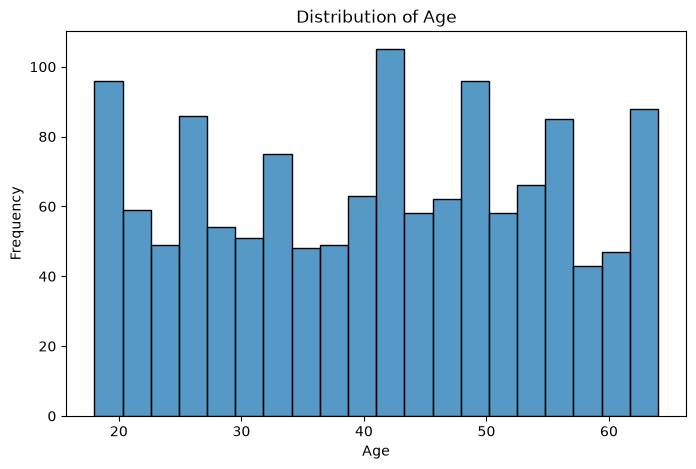

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=insurance,
    x="age",
    bins=20
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig(
    "images/age_distribution.png",
    bbox_inches="tight"
)

plt.show()

### BMI Distribution

The distribution of Body Mass Index (BMI) is examined to understand the variation in BMI values across individuals in the dataset.

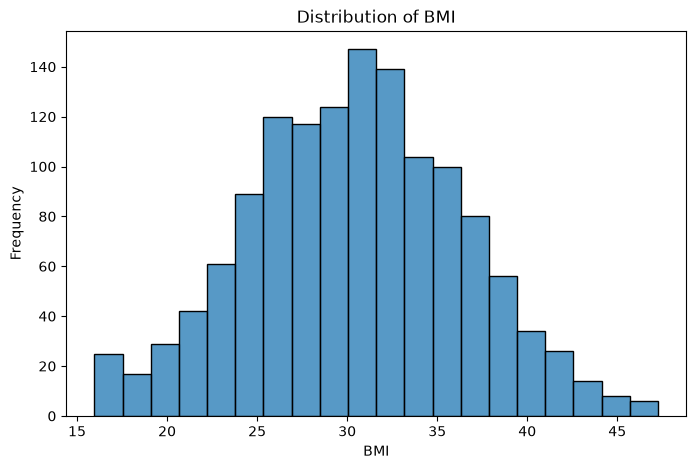

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=insurance,
    x="bmi",
    bins=20
)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.savefig(
    "images/bmi_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Distribution by Sex

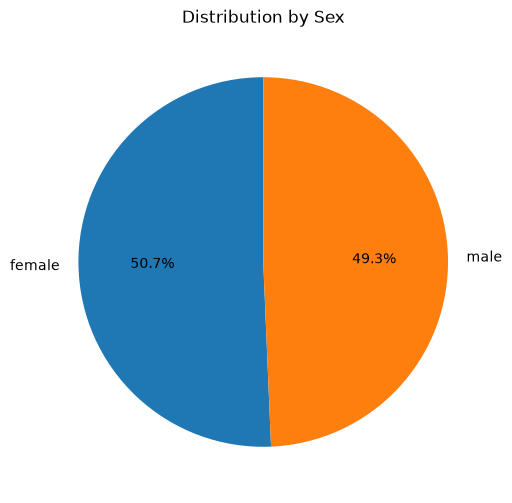

In [26]:
sex_counts = insurance["sex"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution by Sex")

plt.savefig(
    "images/sex_distribution_pie.png",
    bbox_inches="tight"
)

plt.show()

### Distribution of Medical Insurance Charges

The distribution of medical insurance charges is examined because charges represent the target variable that will later be predicted using machine
learning.

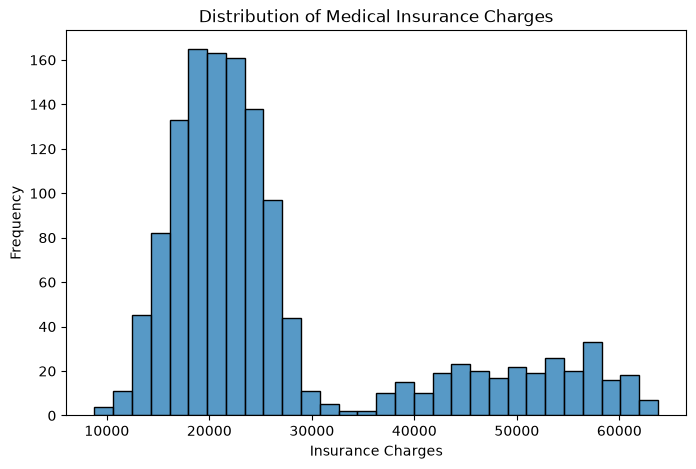

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=insurance,
    x="charges",
    bins=30
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.savefig(
    "images/charges_distribution.png",
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The distribution of medical insurance charges is not symmetric. Most individuals have insurance charges concentrated roughly between 15,000 and 30,000, with the highest frequency around the lower-to-mid 20,000 range.

A smaller group of individuals has much higher charges, extending to above 60,000. This creates a right-skewed distribution, where a relatively small
number of high-cost observations increase the spread of the data.

Overall, the graph shows that most insurance costs are in the lower range, while a smaller proportion of individuals experience substantially higher medical insurance charges.

### Distribution by Smoking Status

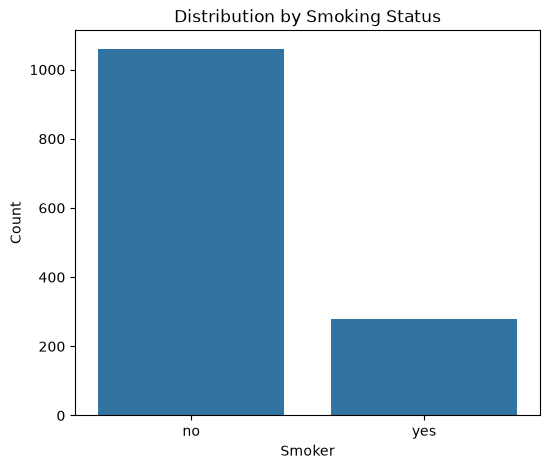

In [27]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=insurance,
    x="smoker"
)

plt.title("Distribution by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Count")

plt.savefig(
    "images/smoker_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Distribution by Region

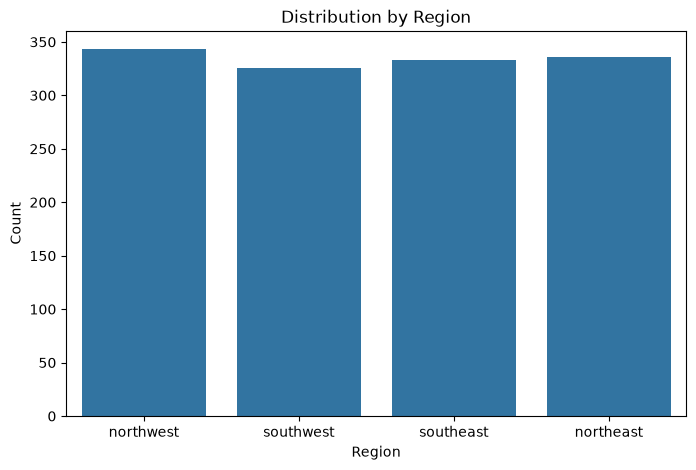

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=insurance,
    x="region"
)

plt.title("Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Count")

plt.savefig(
    "images/region_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Medical Insurance Charges Across Groups

### Average Charges by Smoking Status

Average medical insurance charges are compared between smokers and non-smokers.

In [32]:
insurance.groupby("smoker")["charges"].mean()

smoker
no     20779.834538
yes    50466.105647
Name: charges, dtype: float64

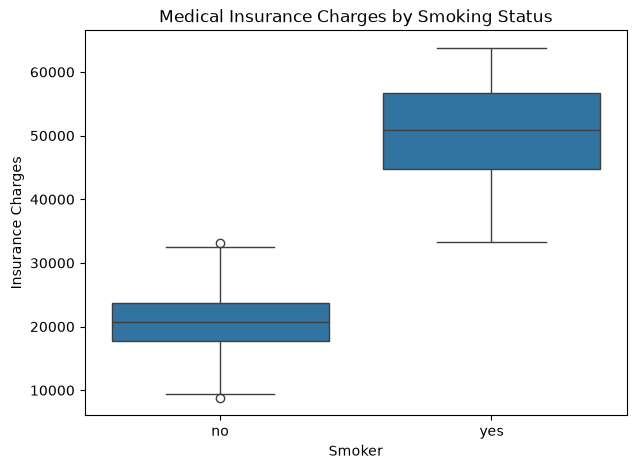

In [33]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=insurance,
    x="smoker",
    y="charges"
)

plt.title("Medical Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.savefig(
    "images/charges_by_smoker.png",
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The boxplot shows a clear difference in medical insurance charges between smokers and non-smokers.

Smokers have substantially higher insurance charges, with a median cost of around 50,000, while the median for non-smokers is around 20,000.

The range of charges for smokers is also generally much higher than for non-smokers. Although there are a few unusual values among non-smokers, the
overall pattern strongly suggests that smoking status is associated with much higher medical insurance costs.

This makes smoking status an important variable to include in the machine learning model.

### Medical Insurance Charges by Sex

Medical insurance charges are compared across the sex categories in the dataset.

In [34]:
insurance.groupby("sex")["charges"].mean()

sex
female    27748.009853
male      26125.835303
Name: charges, dtype: float64

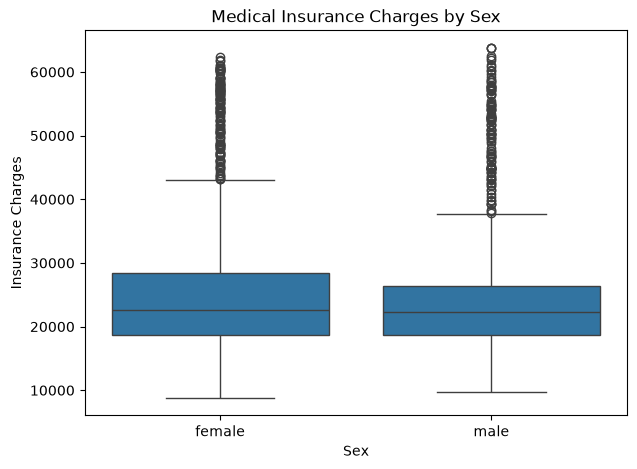

In [35]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=insurance,
    x="sex",
    y="charges"
)

plt.title("Medical Insurance Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Insurance Charges")

plt.savefig(
    "images/charges_by_sex.png",
    bbox_inches="tight"
)

plt.show()

### Medical Insurance Charges by Region

Medical insurance charges are compared across the different geographic regions represented in the dataset.

In [36]:
insurance.groupby("region")["charges"].mean()

region
northeast    26337.418810
northwest    26649.418601
southeast    28373.406967
southwest    26434.767362
Name: charges, dtype: float64

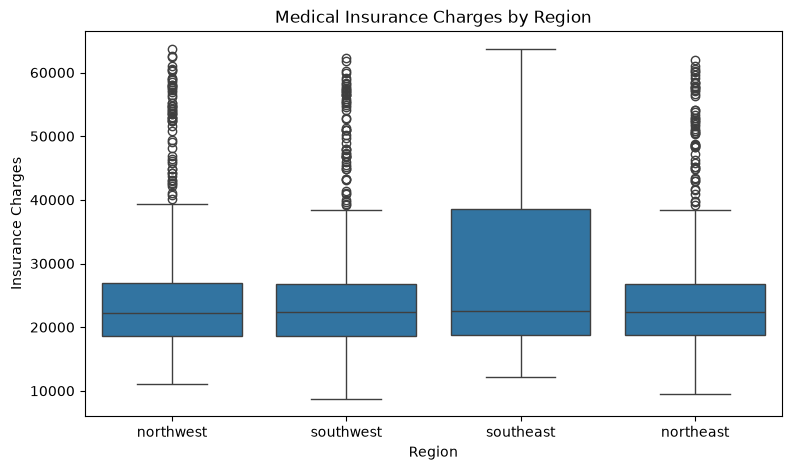

In [37]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=insurance,
    x="region",
    y="charges"
)

plt.title("Medical Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Insurance Charges")

plt.savefig(
    "images/charges_by_region.png",
    bbox_inches="tight"
)

plt.show()

### Medical Insurance Charges by Number of Children

In [38]:
insurance.groupby("children")["charges"].mean()

children
0    26856.599623
1    26489.368115
2    27708.318440
3    26753.892411
4    29068.784167
5    26297.935385
Name: charges, dtype: float64

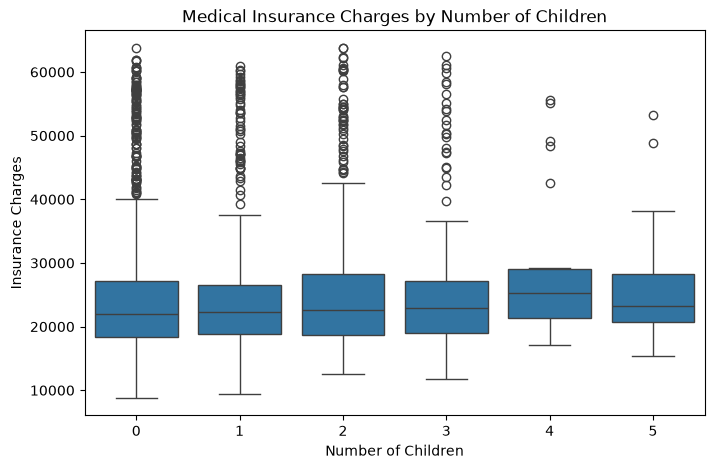

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=insurance,
    x="children",
    y="charges"
)

plt.title("Medical Insurance Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Insurance Charges")

plt.savefig(
    "images/charges_by_children.png",
    bbox_inches="tight"
)

plt.show()

## Relationships Between Numerical Variables

### Age and Medical Insurance Charges

A scatterplot is used to examine the relationship between age and medical insurance charges.

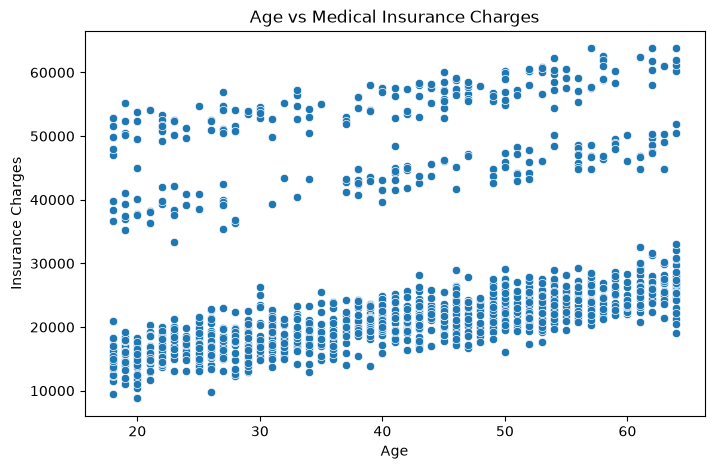

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=insurance,
    x="age",
    y="charges"
)

plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.savefig(
    "images/age_vs_charges.png",
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The scatterplot shows a positive relationship between age and medical insurance charges. In general, insurance charges tend to increase as age increases.

However, the points are widely spread and form several distinct bands, showing that age alone does not explain the full variation in insurance costs. Individuals of similar ages can have very different insurance charges.

Overall, age appears to be related to insurance cost, but other factors such as smoking status and BMI are also likely to play an important role.

### BMI and Medical Insurance Charges

A scatterplot is used to examine the relationship between BMI and medical insurance charges.

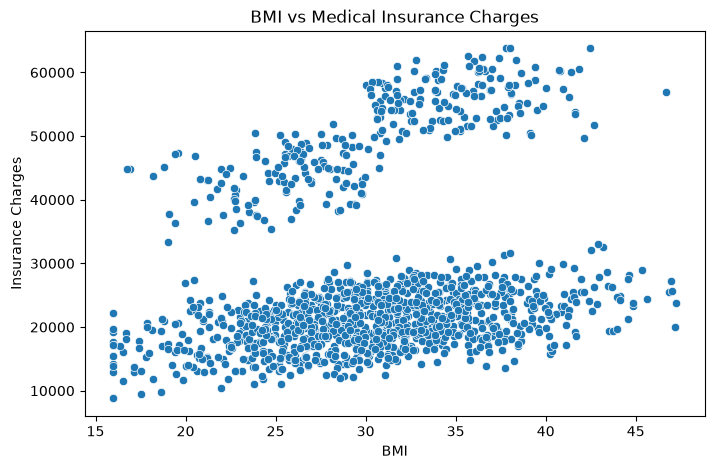

In [41]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=insurance,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.savefig(
    "images/bmi_vs_charges.png",
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The scatterplot shows a weak positive relationship between BMI and medical insurance charges. In general, insurance charges tend to increase slightly
as BMI increases.

However, the points are widely spread, indicating that BMI alone does not explain most of the variation in insurance costs. Individuals with similar BMI values can have very different insurance charges.


The graph also shows a separate group of individuals with much higher charges, suggesting that another factor, such as smoking status, may be contributing to the large differences in medical insurance costs.

## Correlation Analysis

Correlation analysis is used to examine the strength and direction of relationships between the numerical variables in the dataset.

In [42]:
numeric_data = insurance[[
    "age",
    "bmi",
    "children",
    "charges"
]]

In [43]:
correlation = numeric_data.corr()

correlation

,age,bmi,children,charges
age,1.000000,-0.031696,-0.030441,0.264727
bmi,-0.031696,1.000000,-0.014023,0.212934
children,-0.030441,-0.014023,1.000000,0.012825
charges,0.264727,0.212934,0.012825,1.000000


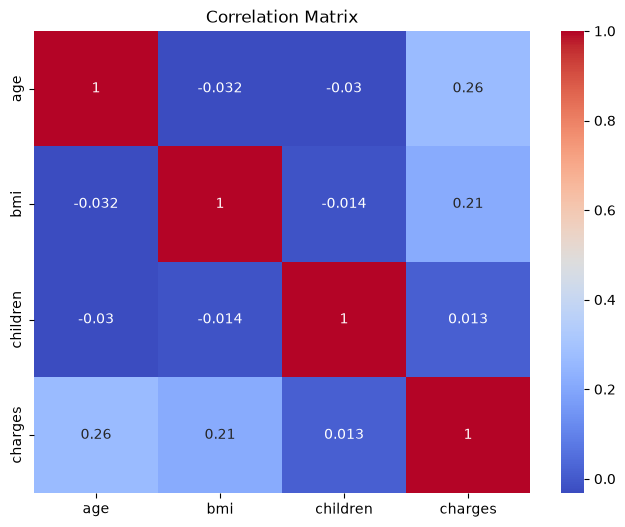

In [44]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig(
    "images/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

#### Interpretation of Correlation Results

The correlation analysis shows that age and BMI have positive relationships with medical insurance charges.

Age has the strongest positive correlation with charges (r = 0.26), indicating a weak positive relationship. This suggests that insurance charges tend to increase as age increases, although the relationship is not very strong.

BMI also has a positive correlation with charges (r = 0.21), which indicates a weak positive relationship between BMI and medical insurance costs.

The number of children has almost no linear relationship with insurance charges (r = 0.01).

The correlations among age, BMI, and number of children are also very close to zero, indicating little linear relationship between these numerical variables.

Overall, none of the numerical variables has a strong correlation with insurance charges when considered individually. This suggests that other variables, especially categorical factors such as smoking status, may also be important
in explaining differences in medical insurance costs.

# Machine Learning

## Medical Insurance Cost Prediction

Linear regression is used to examine whether the available demographic and health-related variables can be used to predict medical insurance charges.

The target variable is medical insurance charges, while the remaining variables are used as predictors.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
insurance_encoded = pd.get_dummies(
    insurance,
    drop_first=True
)

In [47]:
insurance_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,56,27.02,2,23156.27,False,False,True,False,False
1,46,29.40,1,19456.82,True,False,False,False,True
2,32,25.97,5,20395.06,False,False,True,False,False
3,60,30.80,1,26350.83,False,False,True,False,False
4,25,26.81,0,13844.33,False,False,False,False,True


In [48]:
insurance_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,56,27.02,2,23156.27,False,False,True,False,False
1,46,29.40,1,19456.82,True,False,False,False,True
2,32,25.97,5,20395.06,False,False,True,False,False
3,60,30.80,1,26350.83,False,False,True,False,False
4,25,26.81,0,13844.33,False,False,False,False,True


In [49]:
insurance_encoded.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

### Predictor and Target Variables

The predictor variables (X) contain the demographic and health-related characteristics, while medical insurance charges are used as the target variable (y).

In [50]:
X = insurance_encoded.drop("charges", axis=1)

y = insurance_encoded["charges"]

In [51]:
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,56,27.02,2,False,False,True,False,False
1,46,29.40,1,True,False,False,False,True
2,32,25.97,5,False,False,True,False,False
3,60,30.80,1,False,False,True,False,False
4,25,26.81,0,False,False,False,False,True


In [52]:
y.head()

0    23156.27
1    19456.82
2    20395.06
3    26350.83
4    13844.33
Name: charges, dtype: float64

### Training and Testing Data

The dataset is divided into training and testing sets. The training data are used to train the model, while the testing data are used to evaluate how well the model predicts observations it has not seen during training.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1070, 8)
X_test: (268, 8)
y_train: (1070,)
y_test: (268,)


### Linear Regression Model

A linear regression model is trained using the training data.

In [56]:
model = LinearRegression()

In [57]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 243.38, 435.58, 487.7 ,..., 198.53, 38.71,-245.34]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2920
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [58]:
y_pred = model.predict(X_test)

In [60]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
0,21014.92,19922.659340
1,21471.21,22140.977469
2,51841.86,55192.516694
3,35297.12,41441.324219
4,48732.67,52266.052083


### Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² score.

In [61]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1860.9213955783148
RMSE: 2436.6402449846128
R²: 0.9646441340754112


#### Interpretation of Model Evaluation

The linear regression model achieved an MAE of approximately 1,861, an RMSE of approximately 2,437, and an R² score of approximately 0.96.

The MAE means that, on average, the model's predicted insurance charges differ from the actual charges by about 1,861 units.

The RMSE is slightly higher at about 2,437, indicating that some predictions have larger errors and are penalized more heavily.

The R² value of approximately 0.96 means that the model explains about 96% of the variation in medical insurance charges in the test data.

Overall, the model shows very strong predictive performance on this train-test split. 

### Actual vs Predicted Insurance Charges

The actual medical insurance charges are compared with the values predicted by the linear regression model.

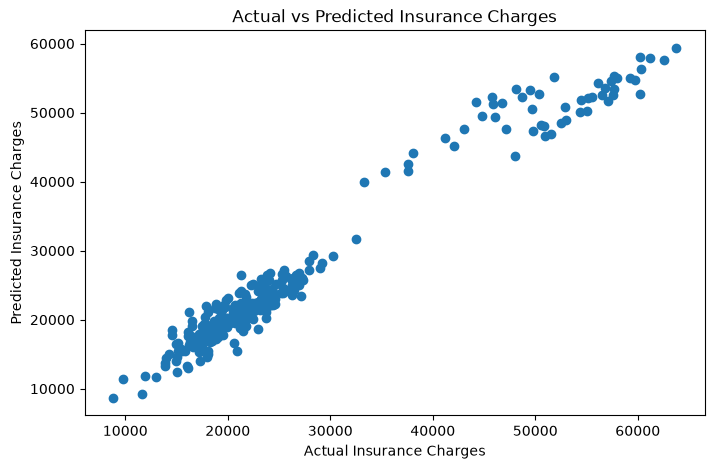

In [62]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.savefig(
    "images/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

#### Interpretation of Actual vs Predicted Charges

The scatterplot shows a strong positive relationship between the actual and
predicted insurance charges.

Most points follow a clear diagonal pattern, indicating that the predicted
values are generally close to the actual values.

The model appears to perform well across both lower and higher insurance charge
values, although some prediction errors are still visible.

This visual result is consistent with the high R² score of approximately 0.96,
which indicates that the model explains a large proportion of the variation in
medical insurance charges.

Overall, the plot suggests that the linear regression model provides accurate
predictions for the available test data.

### Model Coefficients

The regression coefficients are examined to understand how the predictor variables contribute to the model's predictions.

In [63]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Variable,Coefficient
0,age,243.378521
1,bmi,435.578731
2,children,487.701081
3,sex_male,-84.225067
4,smoker_yes,29327.778637
5,region_northwest,198.525093
6,region_southeast,38.708983
7,region_southwest,-245.342138


In [64]:
print("Intercept:", model.intercept_)

Intercept: -2920.3377796768946


## Machine Learning Summary

A multiple linear regression model was developed to predict medical insurance
charges using age, BMI, number of children, sex, smoking status, and region.

The model achieved an MAE of approximately 1,861, an RMSE of approximately
2,437, and an R² score of approximately 0.96. This means that the model
explained about 96% of the variation in medical insurance charges in the test
data. The actual-versus-predicted plot also showed that most predicted values
were close to the actual insurance charges, indicating strong predictive
performance on this train-test split.

The regression coefficients show that smoking status had the largest
relationship with predicted insurance charges. Holding the other variables
constant, smokers were predicted to have insurance charges approximately
29,328 units higher than non-smokers.

Age also had a positive coefficient of approximately 243, meaning that each
additional year of age was associated with an increase of about 243 units in
predicted insurance charges, holding the other variables constant.

BMI had a positive coefficient of approximately 436, indicating that a
one-unit increase in BMI was associated with an increase of about 436 units
in predicted insurance charges. The number of children also had a positive
coefficient of approximately 488 per additional child.

The coefficient for males was approximately -84 relative to females, suggesting
very little difference in predicted insurance charges between the two groups
after controlling for the other variables.

Compared with the reference region, the regional coefficients were relatively
small: northwest was approximately +199, southeast approximately +39, and
southwest approximately -245. This suggests that region contributed much less
to the prediction than variables such as smoking status, BMI, and age.


Overall, the linear regression model performed very well on the available test
data. Smoking status was the strongest predictor in the model, while age, BMI,
and number of children also contributed positively to predicted medical
insurance charges. These results represent statistical associations and should
not be interpreted as proof of causal relationships.